In [ ]:
!uv add torch torchvision matplotlib pillow

Resolved 41 packages in 0.59ms
Checked 40 packages in 3ms


In [71]:
import random
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


In [ ]:
# Configuration
DATA_ROOT = Path("vehicle_classification")
CLASSES = ["Bicycle", "Bus", "Car", "Motorcycle", "NonVehicles", "Taxi", "Truck", "Van"]

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
TRAIN_RATIO = 0.8

IMG_SIZE = 64
BATCH_SIZE = 32
NUM_EPOCHS = 256
LEARNING_RATE = 1e-3

assert DATA_ROOT.exists(), f"Dataset folder not found: {DATA_ROOT.resolve()}"

print("Data root:", DATA_ROOT.resolve())
print("Classes:", CLASSES)

Data root: /home/user/Documents/CNN Classification/vehicle_classification
Classes: ['Bicycle', 'Bus', 'Car', 'Motorcycle', 'NonVehicles', 'Taxi', 'Truck', 'Van']


In [73]:
class VehicleDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        image_path, label = self.samples[idx]
        image = Image.open(image_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

samples = []
for label_idx, cls in enumerate(CLASSES):
    class_dir = DATA_ROOT / cls
    assert class_dir.exists(), f"Missing class folder: {class_dir}"

    class_files = [
        p for p in class_dir.rglob("*")
        if p.suffix.lower() in IMAGE_EXTS
    ]
    assert class_files, f"No images found for class '{cls}' in {class_dir}"

    samples.extend((p, label_idx) for p in class_files)

print(f"Total samples found: {len(samples)}")

Total samples found: 26378


In [108]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5), # Helps with generalizing?
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

indices_per_class = {i: [] for i in range(len(CLASSES))}
for idx, (_, label) in enumerate(samples):
    indices_per_class[label].append(idx)

train_indices, test_indices = [], []
rng = random.Random(SEED)

for label_idx, idxs in indices_per_class.items():
    rng.shuffle(idxs)
    split = max(1, int(len(idxs) * TRAIN_RATIO))
    if split >= len(idxs):
        split = len(idxs) - 1

    train_indices.extend(idxs[:split])
    test_indices.extend(idxs[split:])

train_dataset = Subset(VehicleDataset(samples, transform=train_transform), train_indices)
test_dataset = Subset(VehicleDataset(samples, transform=test_transform), test_indices)

num_workers = 0

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=num_workers
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=num_workers
)

print(f"Train samples: {len(train_dataset)}")
print(f"Test samples:  {len(test_dataset)}")

Train samples: 21098
Test samples:  5280


In [115]:
class CNN(nn.Module):
    def __init__(self, num_classes = 8):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size = 3, padding = 1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace = True),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size = 3, padding = 1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace = True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size = 3, padding = 1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace = True),\
            nn.MaxPool2d(2),

            nn.Conv2d(64, 64, kernel_size = 3, padding = 1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace = True),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.2), # Helps with overfitting
            nn.Linear(64, 64),
            nn.ReLU(inplace = True),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = CNN(num_classes = len(CLASSES)).to(device)
loss_function = nn.CrossEntropyLoss()
# optimizer = optim.SGD(model.parameters(), lr = LEARNING_RATE)
optimizer = optim.Adam(model.parameters(), lr = LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode = 'min', factor = 0.5, patience = 5)

print(model)

CNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, 

In [116]:
def run_epoch(model, dataloader, loss_function, optimizer=None):
    if optimizer: is_train = True
    else: is_train = False

    if is_train: model.train()
    else: model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.set_grad_enabled(is_train):
        for images, labels in dataloader:
            images = images.to(device, non_blocking = True)
            labels = labels.to(device, non_blocking = True)

            outputs = model(images)
            loss = loss_function(outputs, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim = 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total # average loss and average accuracy

In [117]:
history = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": []
}

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = run_epoch(model, train_loader, loss_function, optimizer = optimizer)
    test_loss, test_acc = run_epoch(model, test_loader, loss_function, optimizer = None)
    scheduler.step(test_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)
    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
        f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f} | Learning rate: {optimizer.param_groups[0]['lr']}"
    )

    if epoch % 12 == 0:
        torch.save(model.state_dict(), "model.pth")

Epoch 01/128 | Train Loss: 1.0161, Train Acc: 0.6460 | Test Loss: 0.8551, Test Acc: 0.6833 | Learning rate: 0.001
Epoch 02/128 | Train Loss: 0.7991, Train Acc: 0.7113 | Test Loss: 0.8869, Test Acc: 0.6932 | Learning rate: 0.001
Epoch 03/128 | Train Loss: 0.7409, Train Acc: 0.7357 | Test Loss: 0.7297, Test Acc: 0.7360 | Learning rate: 0.001
Epoch 04/128 | Train Loss: 0.6903, Train Acc: 0.7520 | Test Loss: 0.6836, Test Acc: 0.7530 | Learning rate: 0.001


KeyboardInterrupt: 

In [107]:
final_train_acc = history["train_acc"][-1]
final_test_acc = history["test_acc"][-1]

print(f"Final training accuracy: {final_train_acc * 100:.2f}%")
print(f"Final testing  accuracy: {final_test_acc * 100:.2f}%")

Final training accuracy: 83.44%
Final testing  accuracy: 83.20%


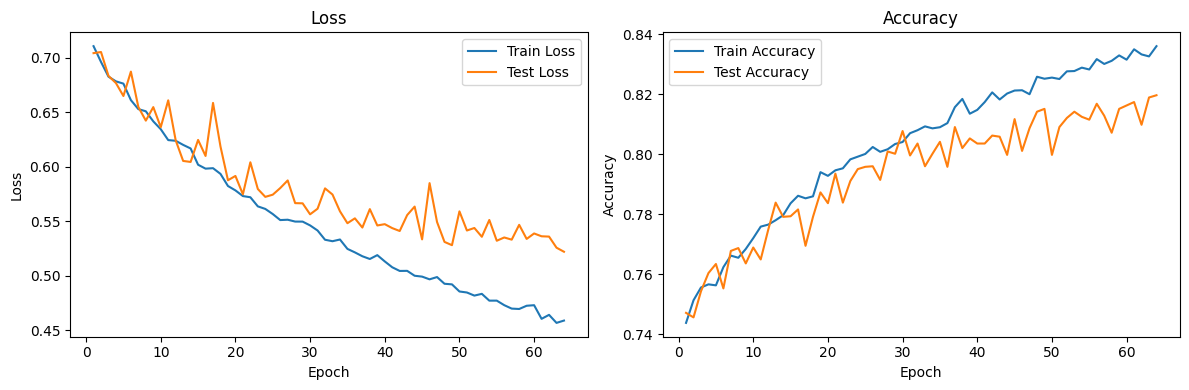

In [97]:
import matplotlib.pyplot as plt

epochs = list(range(1, len(history["train_loss"]) + 1))

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], label = "Train Loss")
plt.plot(epochs, history["test_loss"], label = "Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], label = "Train Accuracy")
plt.plot(epochs, history["test_acc"], label = "Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()